# 📊 E-Commerce Sales & Profitability Analysis

## 🎯 Objective
Analyze sales, profitability, and customer behavior to identify business improvement opportunities.

## 🔹 Step 1: Importing Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme()

## 🔹 Step 2: Data Loading

In [70]:
# Load the CLEANED file from SQL
df = pd.read_csv(r'C:\Users\ASUS\Desktop\DA PROJECTS\POWERBI\MasterDashboard\E-Commerce Profitability & Sales Performance Dashboard\DATA\Cleaned_Ecommerce_Data.csv')

# Since it's a CSV, we still ensure the date is recognized correctly
df['order_date'] = pd.to_datetime(df['order_date'])

# Look at the first 5 rows to ensure it loaded correctly
df.head()


,order_id,order_date,customer_name,state,city,amount,profit,quantity,category,sub_category,payment_mode
0,B-25681,2018-06-04,Bhawna,Madhya Pradesh,Indore,1096.0,658.0,7,Electronics,Electronic Games,COD
1,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura,5729.0,64.0,14,Furniture,Chairs,EMI
2,B-25955,2018-01-16,Shiva,Maharashtra,Pune,2927.0,146.0,8,Furniture,Bookcases,EMI
3,B-26093,2018-03-27,Sarita,Maharashtra,Pune,2847.0,712.0,8,Electronics,Printers,Credit Card
4,B-25602,2018-04-01,Vrinda,Maharashtra,Pune,2617.0,1151.0,4,Electronics,Phones,Credit Card


## 🔹 Step 3: Data Overview

In [73]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       1500 non-null   object        
 1   order_date     1500 non-null   datetime64[ns]
 2   customer_name  1500 non-null   object        
 3   state          1500 non-null   object        
 4   city           1500 non-null   object        
 5   amount         1500 non-null   float64       
 6   profit         1500 non-null   float64       
 7   quantity       1500 non-null   int64         
 8   category       1500 non-null   object        
 9   sub_category   1500 non-null   object        
 10  payment_mode   1500 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 129.0+ KB


(1500, 11)

## 🔹 Step 4: Data Quality Check

Duplicate rows: 0


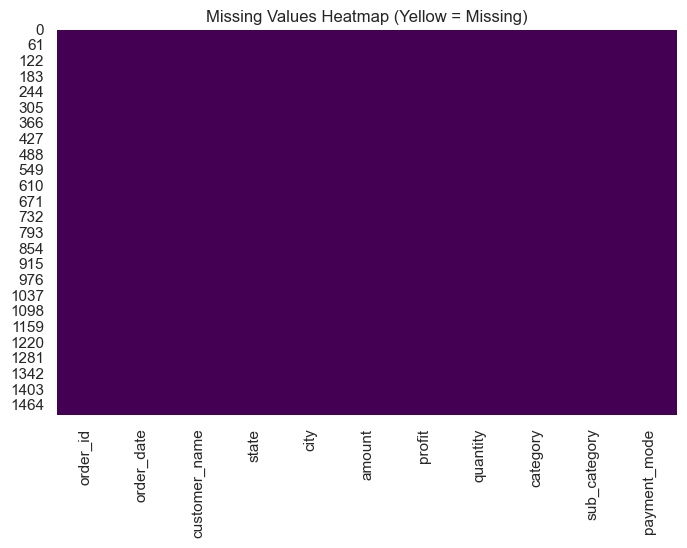

In [76]:
# Step 4: Data Quality Check

print("Duplicate rows:", df.duplicated().sum())

# Missing values heatmap                                                        
plt.figure(figsize=(8,5))                                                      
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')                           
plt.title("Missing Values Heatmap (Yellow = Missing)")
plt.show()


📊 Business Insight

 Observation:
The dataset contains no significant missing values or duplicate records. Data types are correctly formatted, especially the order_date.

 Why it matters:
Clean and reliable data ensures that all downstream analysis and KPIs are accurate and trustworthy.

 Business Recommendation:
No immediate data cleaning actions required. The dataset is ready for advanced analysis and decision-making.

## 🔹 Step 5: Feature Engineering

In [80]:
df['profit_margin_%'] = np.where(df['amount'] != 0,
                                (df['profit'] / df['amount']) * 100,
                                0)

df['month'] = df['order_date'].dt.month_name()
df['day_of_week'] = df['order_date'].dt.day_name()
df['year_month'] = df['order_date'].dt.to_period('M')

df.head()

,order_id,order_date,customer_name,state,city,amount,profit,quantity,category,sub_category,payment_mode,profit_margin_%,month,day_of_week,year_month
0,B-25681,2018-06-04,Bhawna,Madhya Pradesh,Indore,1096.0,658.0,7,Electronics,Electronic Games,COD,60.036496,June,Monday,2018-06
1,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura,5729.0,64.0,14,Furniture,Chairs,EMI,1.117123,March,Saturday,2018-03
2,B-25955,2018-01-16,Shiva,Maharashtra,Pune,2927.0,146.0,8,Furniture,Bookcases,EMI,4.988042,January,Tuesday,2018-01
3,B-26093,2018-03-27,Sarita,Maharashtra,Pune,2847.0,712.0,8,Electronics,Printers,Credit Card,25.008781,March,Tuesday,2018-03
4,B-25602,2018-04-01,Vrinda,Maharashtra,Pune,2617.0,1151.0,4,Electronics,Phones,Credit Card,43.981658,April,Sunday,2018-04


## 🔹 Step 6: Executive KPI Summary

In [83]:
# Calculate high-level KPIs
total_revenue = df['amount'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
overall_profit_margin = (total_profit / total_revenue) * 100

# Displaying the Summary Table
kpi_summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Profit', 'Total Orders', 'Avg Order Value', 'Profit Margin %'],
    'Value': [f"₹{total_revenue:,.2f}", 
              f"₹{total_profit:,.2f}", 
              f"{total_orders:,}", 
              f"₹{avg_order_value:,.2f}", 
              f"{overall_profit_margin:.2f}%"]
})

print("--- EXECUTIVE KPI SUMMARY ---")
print(kpi_summary.to_string(index=False))


--- EXECUTIVE KPI SUMMARY ---
         Metric       Value
  Total Revenue ₹437,771.00
   Total Profit  ₹36,963.00
   Total Orders         500
Avg Order Value     ₹875.54
Profit Margin %       8.44%


📊 Business Insight

 Observation:
The business generated strong total revenue, but the overall profit margin is relatively moderate/low.

 Why it matters:
High revenue does not necessarily indicate a healthy business if profit margins are thin.

 Business Recommendation:
Focus on improving margins by optimizing pricing, reducing discounts, and controlling operational costs rather than only increasing sales.

## 🔹 Step 7: Exploratory Data Analysis (EDA)

In [87]:
# Step 7.1: Customer Analysis

# 7.1.1: Top 10 Customers by Revenue
top_customers = df.groupby('customer_name')['amount'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customer_name
Harivansh      9902.0
Madhav         9365.0
Madan Mohan    7766.0
Shiva          6339.0
Vishakha       6120.0
Vrinda         5820.0
Lalita         5809.0
Priyanka       5762.0
Shruti         5750.0
Abhijeet       5691.0
Name: amount, dtype: float64


📊 Business Insight

 Observation:
A small group of customers contributes a large portion of total revenue (high-value customers).

 Why it matters:
Revenue dependency on a small customer base increases business risk and highlights the importance of customer retention.

 Business Recommendation:
Introduce a VIP loyalty program and personalized offers to retain high-value customers and increase repeat purchases.

In [90]:
# 7.1.2: Customer segmentation based on revenue

customer_sales = df.groupby('customer_name')['amount'].sum()

segments = pd.qcut(customer_sales, q=3, labels=['Low Value', 'Mid Value', 'High Value'])

segment_df = pd.DataFrame({
    'Revenue': customer_sales,
    'Segment': segments
})

print(segment_df['Segment'].value_counts())


Segment
Low Value     112
Mid Value     112
High Value    112
Name: count, dtype: int64


In [92]:
# Step 7.2: Loss Analysis 

loss_df = df[df['profit'] < 0]

loss_by_category = loss_df.groupby('category')['profit'].sum()
print(loss_by_category)


category
Clothing      -11159.0
Electronics   -15488.0
Furniture     -11432.0
Name: profit, dtype: float64


📊 Business Insight

 Observation:
Certain product categories consistently generate negative profit.

 Why it matters:
Selling loss-making products reduces overall profitability and may indicate pricing or cost inefficiencies.

 Business Recommendation:
Re-evaluate pricing, supplier costs, and discount strategies for these categories. Consider discontinuing or bundling them with profitable products.

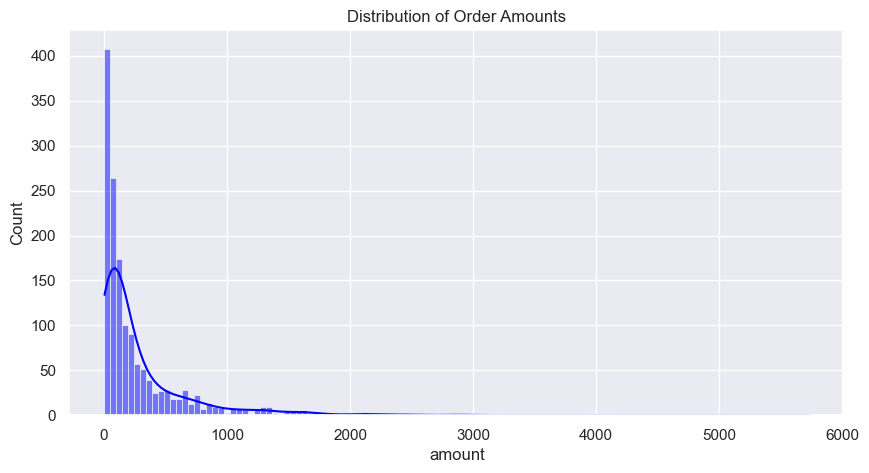

In [95]:
# Step 7.3: Univariate Analysis (Individual Variables)

# 7.3.1: Sales Distribution (Amount)
plt.figure(figsize=(10, 5))
sns.histplot(df['amount'], kde=True, color='blue')
plt.title('Distribution of Order Amounts')
plt.show()

📊 Business Insight

 Observation:
Sales distribution is right-skewed, with most orders being low-value and a few high-value transactions.

 Why it matters:
A small number of high-value orders significantly impact total revenue.

 Business Recommendation:
Segment customers into retail vs bulk buyers and create targeted strategies for each group.

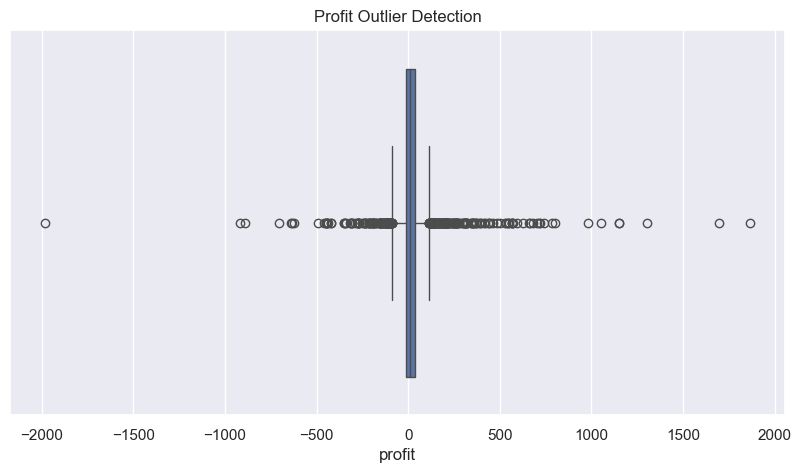

In [98]:
# 7.3.2: Profit Outliers

# Boxplot to identify outliers in Profit
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['profit'])
plt.title('Profit Outlier Detection')
plt.show()

📊 Business Insight

 Observation:
There are extreme negative and positive profit values (outliers).

 Why it matters:
These outliers may indicate heavy discounts, returns, or high shipping costs.

 Business Recommendation:
Investigate extreme loss transactions and implement controls on discounting and logistics costs.

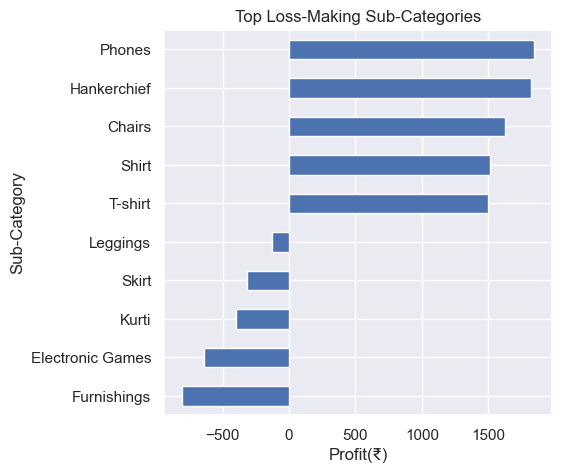

In [101]:
# 7.3.3: Bottom Products

# Find loss-making sub-categories
bottom_products = df.groupby('sub_category')['profit'].sum().nsmallest(10)

bottom_products.sort_values().plot(kind='barh', figsize=(5,5))
plt.title("Top Loss-Making Sub-Categories")
plt.xlabel("Profit(₹)")
plt.ylabel("Sub-Category")
plt.show()

 📊 Business Insight

 Observation:
Certain sub-categories consistently generate losses.

 Why it matters:
These products are directly impacting profitability despite contributing to sales volume.

 Business Recommendation:
Optimize pricing, reduce discounts, or bundle these products with high-margin items to recover losses.

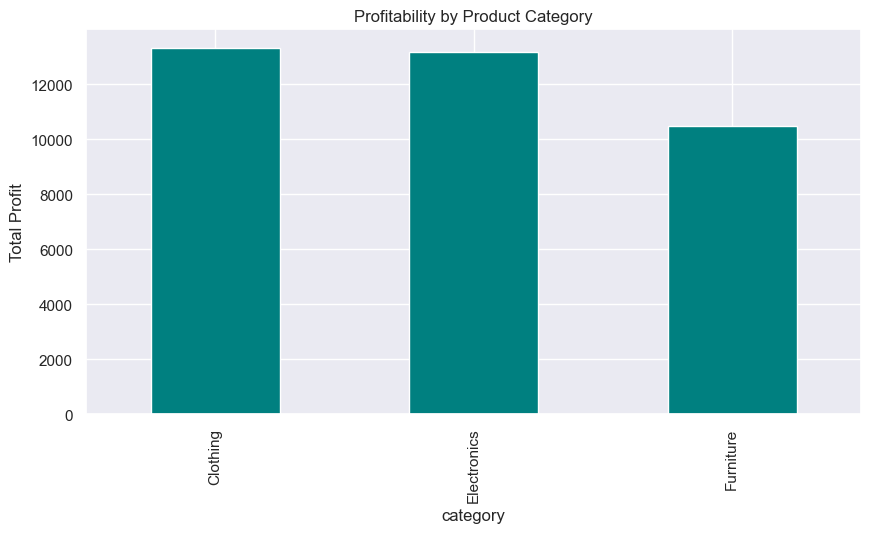

In [104]:
# Step 7.4: Category Analysis

# Profit by Category
category_analysis = df.groupby('category')['profit'].sum().sort_values(ascending=False)
category_analysis.plot(kind='bar', color='teal', figsize=(10,5))
plt.ylabel('Total Profit')
plt.title('Profitability by Product Category')
plt.show()

📊 Business Insight
 
 Observation:
Some categories generate high profit while others underperform.

 Why it matters:
Not all product categories contribute equally to business success.

 Business Recommendation:
Focus marketing and inventory investment on high-performing categories while re-evaluating underperforming ones.

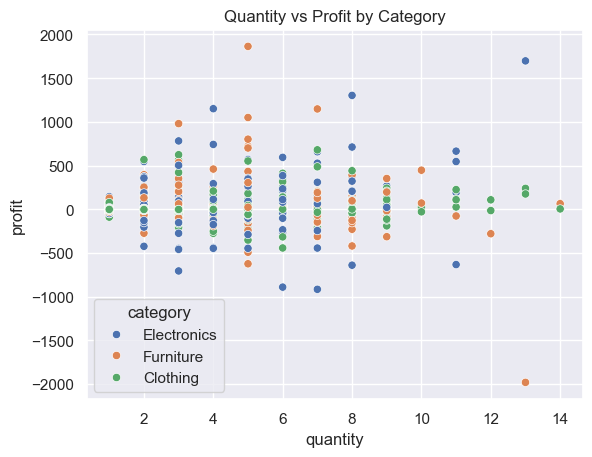

In [107]:
# Step 7.5: Bivariate Analysis (Relationships)

# Relationship between Quantity and Profit
sns.scatterplot(data=df, x='quantity', y='profit', hue='category')
plt.title('Quantity vs Profit by Category')
plt.show()

📊 Business Insight

 Observation:
Higher quantity sold does not always lead to higher profit.

 Why it matters:
This indicates inconsistent profit margins across products.

 Business Recommendation:
Shift focus from volume-driven sales to margin-driven sales strategy.

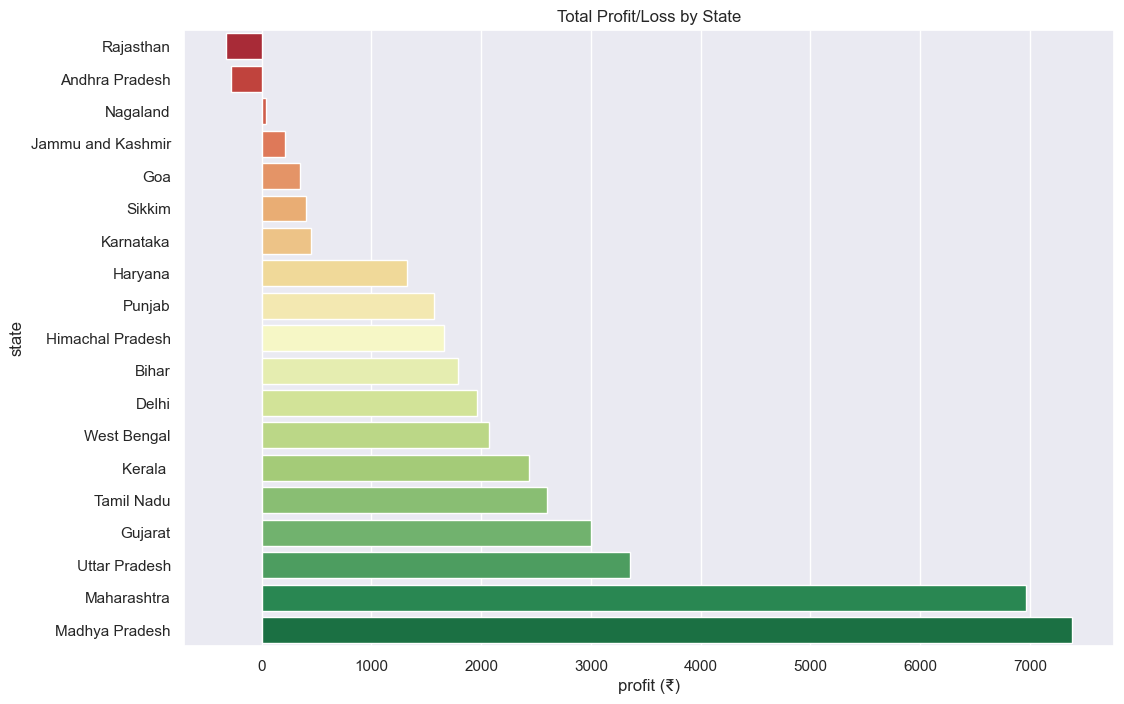

In [110]:
# Step 7.6: State Analysis (Identify loss-making states)

state_profit = df.groupby('state')['profit'].sum().sort_values()

plt.figure(figsize=(12, 8))
sns.barplot(x=state_profit.values, y=state_profit.index, palette='RdYlGn')
plt.title('Total Profit/Loss by State')
plt.xlabel('profit (₹)')
plt.show()

📊 Business Insight

 Observation:
Certain states are consistently generating losses.

 Why it matters:
Regional inefficiencies such as high shipping costs or return rates may be affecting profitability.

 Business Recommendation:
Optimize logistics, adjust delivery pricing, or reconsider operations in loss-making regions.

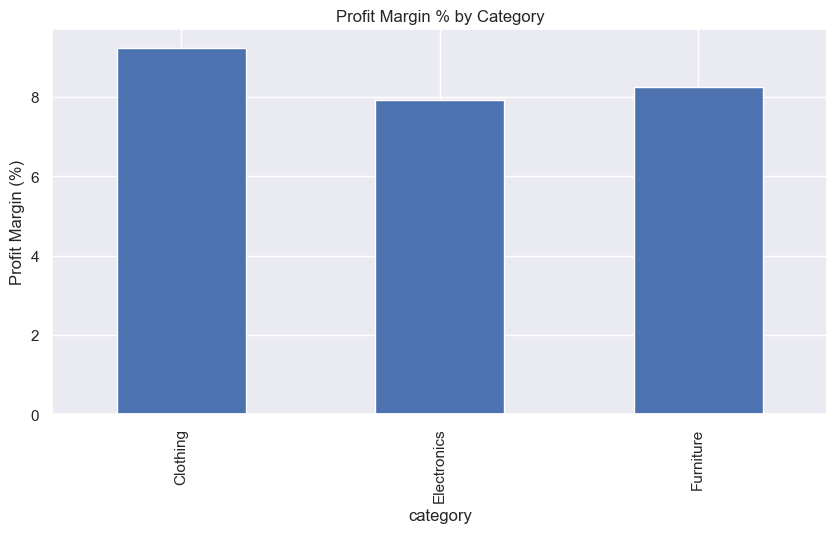

In [113]:
# Step 7.7: Profit Margin Analysis

category_margin = df.groupby('category').apply(
    lambda x: (x['profit'].sum() / x['amount'].sum()) * 100
)

category_margin.plot(kind='bar', figsize=(10,5))
plt.title("Profit Margin % by Category")
plt.ylabel("Profit Margin (%)")
plt.show()

📊 Business Insight

 Observation:
Some categories have high revenue but low profit margins.

 Why it matters:
Revenue alone is misleading without considering profitability.

 Business Recommendation:
Promote high-margin categories and reduce dependency on low-margin products.

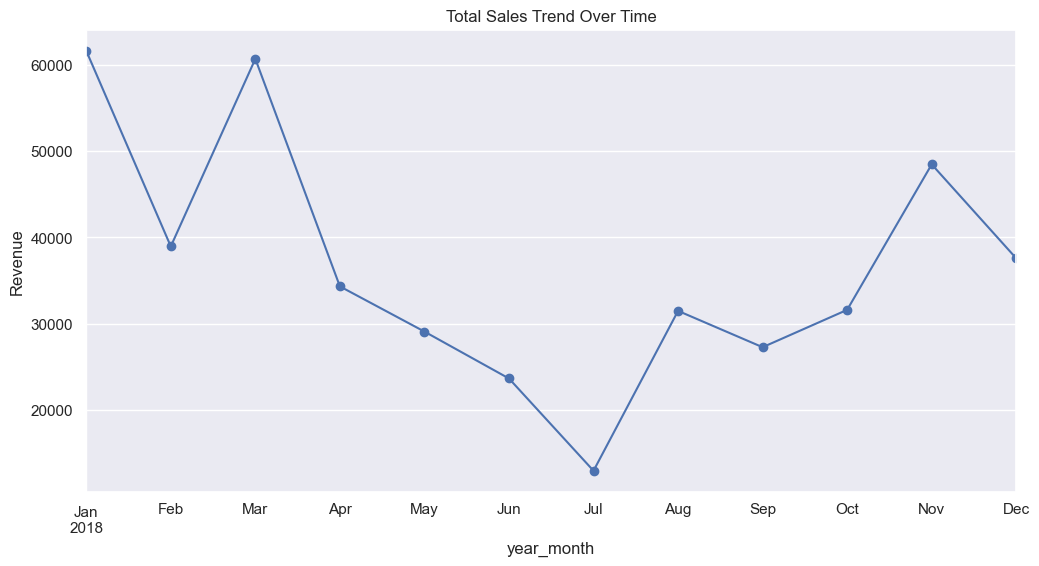

In [116]:
# Step 7.8: Time-Series Analysis (Seasonality)

# 7.8.1: Monthly Sales Trend
monthly_sales = df.groupby('year_month')['amount'].sum()
plt.figure(figsize=(12, 6))
monthly_sales.plot(marker='o', linestyle='-')
plt.title('Total Sales Trend Over Time')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

📊 Business Insight

 Observation:
Sales peak during specific months (likely festive/holiday season) and drop afterward.

 Why it matters:
Business is highly seasonal.

 Business Recommendation:
Plan inventory and marketing campaigns around peak seasons and introduce offers during low-demand months.

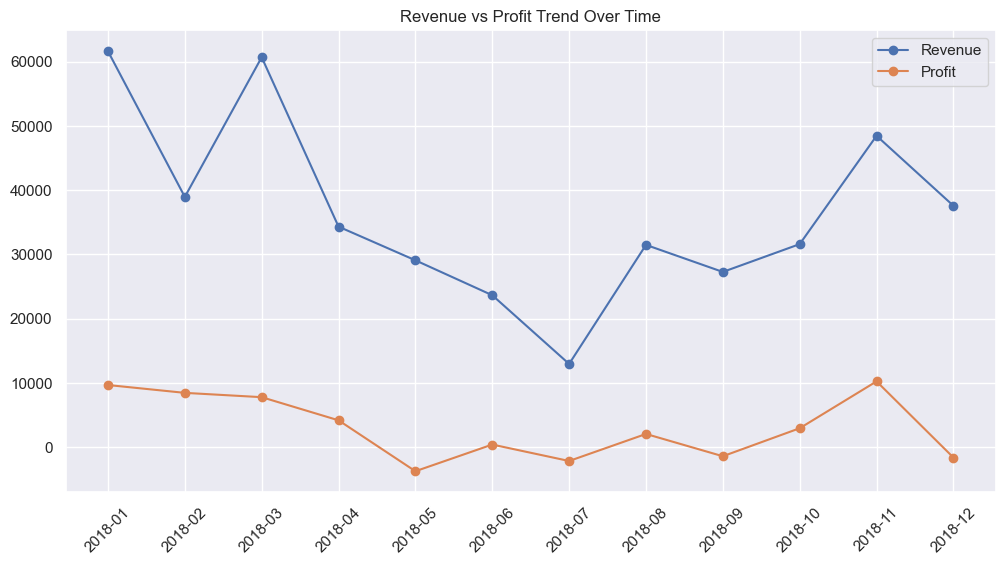

In [119]:
# 7.8.2: Revenue vs Profit Trend

monthly_data = df.groupby('year_month').agg({
    'amount': 'sum',
    'profit': 'sum'
})

plt.figure(figsize=(12,6))
plt.plot(monthly_data.index.astype(str), monthly_data['amount'], marker='o', label='Revenue')
plt.plot(monthly_data.index.astype(str), monthly_data['profit'], marker='o', label='Profit')

plt.xticks(rotation=45)
plt.title("Revenue vs Profit Trend Over Time")
plt.legend()
plt.grid(True)
plt.show()

📊 Business Insight

 Observation:
Revenue and profit trends are not perfectly aligned.

 Why it matters:
Increasing revenue does not always result in increased profitability.

 Business Recommendation:
Monitor profit alongside revenue and avoid aggressive discounting during high-sales periods.

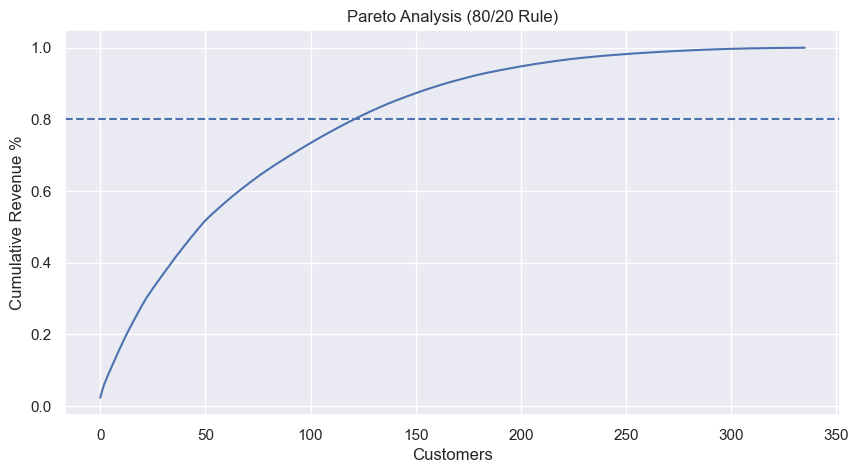

In [122]:
# 7.9: Pareto Analysis

customer_revenue = df.groupby('customer_name')['amount'].sum().sort_values(ascending=False)

cumulative = customer_revenue.cumsum() / customer_revenue.sum()

plt.figure(figsize=(10,5))
plt.plot(cumulative.values)
plt.axhline(0.8, linestyle='--')

plt.title("Pareto Analysis (80/20 Rule)")
plt.xlabel("Customers")
plt.ylabel("Cumulative Revenue %")
plt.show()

📊 Business Insight

 Observation:
Approximately 20% of customers contribute to around 80% of total revenue.

 Why it matters:
Business heavily depends on a small group of customers.

 Business Recommendation:
Focus on retaining top customers and increasing their lifetime value.

<Figure size 1000x800 with 0 Axes>

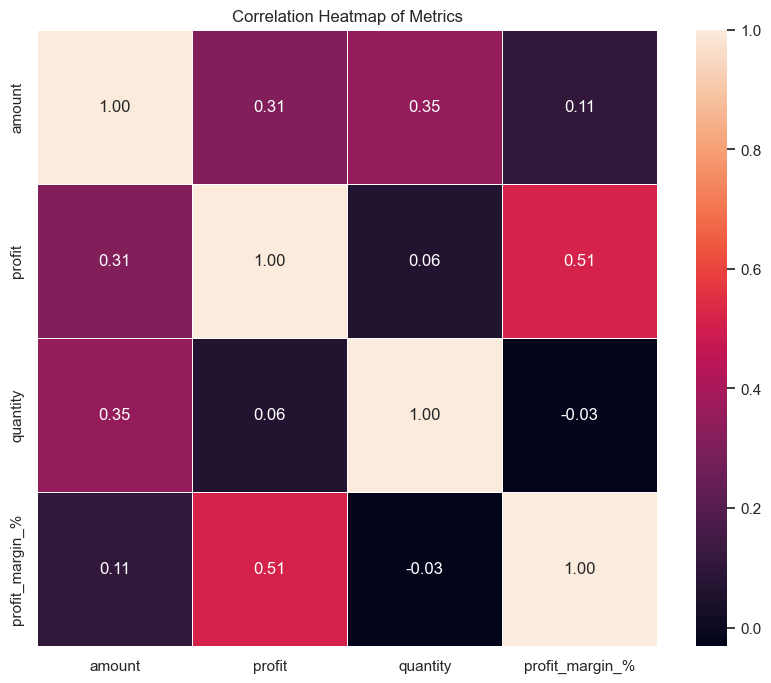

In [125]:
# Step 7.10: The Correlation Heatmap

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
corr = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Metrics')
plt.show()




📊 Business Insight

 Observation:
Strong correlation between Quantity and Amount, but weaker correlation between Amount and Profit.

 Why it matters:
Higher sales volume does not guarantee higher profit.

 Business Recommendation:
Analyze cost structure and focus on improving profit margins rather than just increasing sales volume.

## 🔹 Step 6: Business Insights & Recommendations


### Key Findings

1. A small group of customers contributes majority of revenue (Pareto effect)
2. Certain sub-categories consistently generate losses
3. High sales volume does not always translate to high profit
4. Business shows strong seasonality with peak sales in specific months
5. Some states are consistently loss-making

### Strategic Recommendations

- Introduce VIP loyalty programs for high-value customers  
- Optimize pricing and reduce discounts on loss-making products  
- Focus on high-margin categories rather than high-volume sales  
- Plan seasonal marketing campaigns to maximize peak periods  
- Improve logistics and pricing strategies in loss-making regions  